              Model            Condition       MSE ModelUnified
0         GraphSAGE             Baseline  0.035153    GraphSAGE
1             GUNet             Baseline  0.035919        GUNet
2               MLP             Baseline  0.041603          MLP
3          PointNet             Baseline  0.018942     PointNet
4   GraphSAGEGlobal     PointMAE_default  0.022403    GraphSAGE
5       GUNetGlobal     PointMAE_default  0.035941        GUNet
6         MLPGlobal     PointMAE_default  0.023947          MLP
7    PointNetGlobal     PointMAE_default  0.024825     PointNet
8   GraphSAGEGlobal  PointMAE_normalized  0.029011    GraphSAGE
9       GUNetGlobal  PointMAE_normalized  0.030908        GUNet
10        MLPGlobal  PointMAE_normalized  0.029775          MLP
11   PointNetGlobal  PointMAE_normalized  0.050762     PointNet
12  GraphSAGEGlobal     PointNet_default  0.026728    GraphSAGE
13      GUNetGlobal     PointNet_default  0.029967        GUNet
14        MLPGlobal     PointNet_default

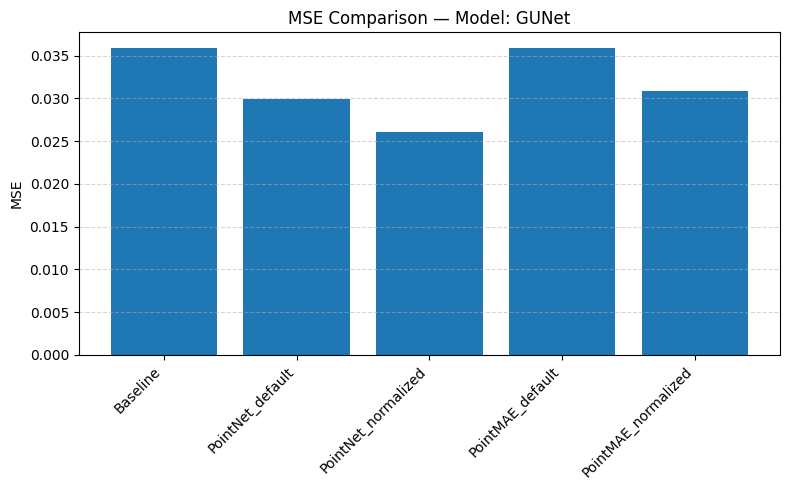

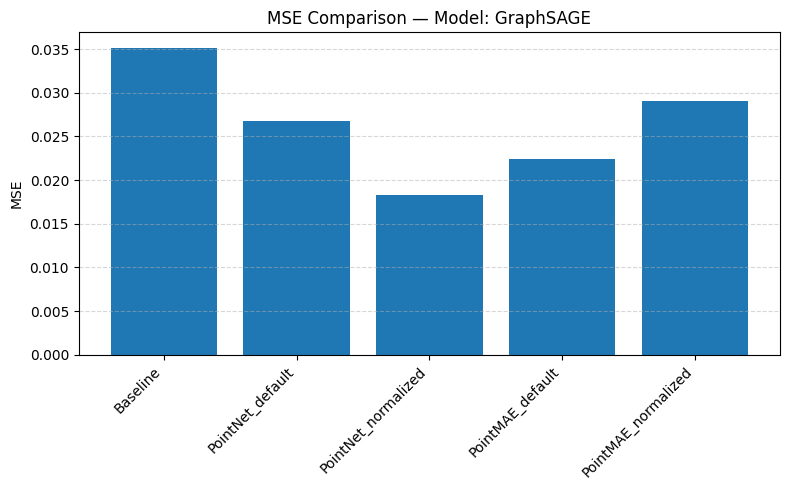

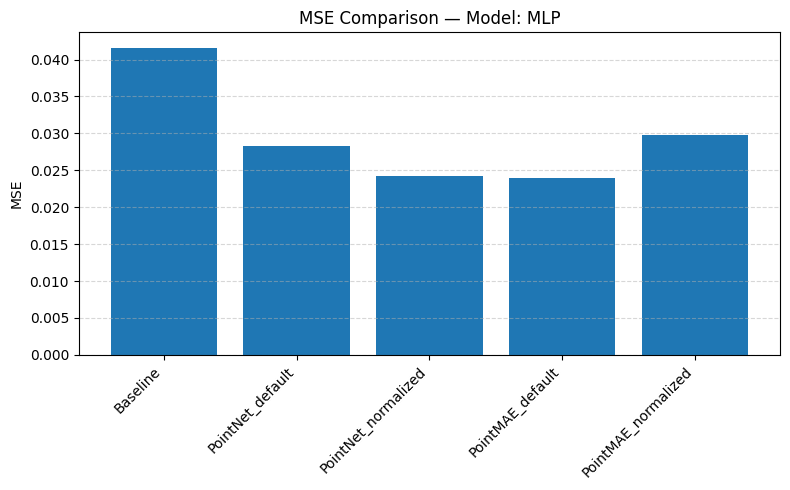

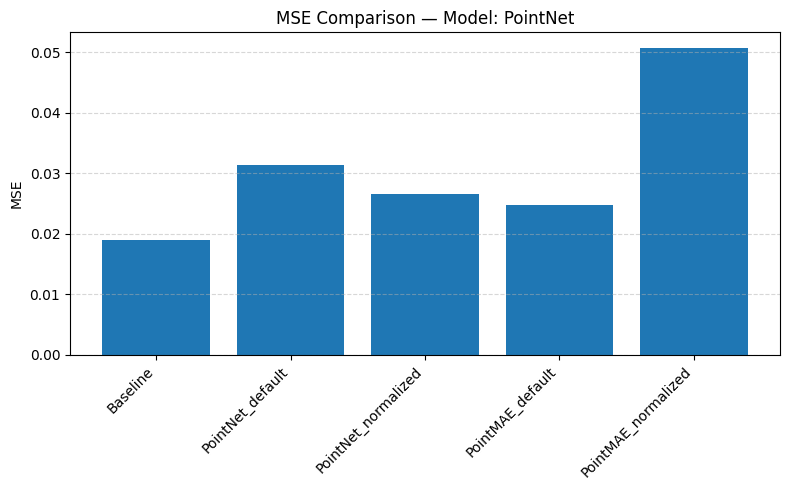

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------
# Compute metrics (simple)
# ---------------------------------------
def compute_metrics(model_path):
    files = os.listdir(model_path)

    if "true_coefs.npy" not in files or "pred_coefs_mean.npy" not in files:
        return None

    true = np.load(os.path.join(model_path, "true_coefs.npy"))
    pred = np.load(os.path.join(model_path, "pred_coefs_mean.npy"))

    mse  = np.mean((pred - true)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pred - true))

    return {"MSE": mse, "RMSE": rmse, "MAE": mae}


root = "."


# ---------------------------------------
# Scan all all_score* folders
# ---------------------------------------
rows = []

for folder in os.listdir(root):
    if "all_score" not in folder:
        continue

    f = folder.lower()

    if   "baseline"   in f: condition = "Baseline"
    elif "pointnet"   in f and "default"    in f: condition = "PointNet_default"
    elif "pointnet"   in f and "normalized" in f: condition = "PointNet_normalized"
    elif "pointmae"   in f and "default"    in f: condition = "PointMAE_default"
    elif "pointmae"   in f and "normalized" in f: condition = "PointMAE_normalized"
    else:
        continue

    dataset_path = os.path.join(root, folder)

    for task in os.listdir(dataset_path):
        task_path = os.path.join(dataset_path, task)
        if not os.path.isdir(task_path):
            continue

        for model in os.listdir(task_path):
            model_path = os.path.join(task_path, model)
            if not os.path.isdir(model_path):
                continue

            metrics = compute_metrics(model_path)
            if metrics is None:
                continue

            rows.append({
                "Model": model,
                "Condition": condition,
                "MSE": metrics["MSE"]
            })


# ---------------------------------------
# DataFrame + Normalisation
# ---------------------------------------
df = pd.DataFrame(rows)

model_map = {
    "GraphSAGE": "GraphSAGE",
    "GraphSAGEGlobal": "GraphSAGE",
    "GUNet": "GUNet",
    "GUNetGlobal": "GUNet",
    "MLP": "MLP",
    "MLPGlobal": "MLP",
    "PointNet": "PointNet",
    "PointNetGlobal": "PointNet"
}

df["ModelUnified"] = df["Model"].map(model_map)

print(df)


# ---------------------------------------
# Barplots
# ---------------------------------------
conditions_order = [
    "Baseline",
    "PointNet_default",
    "PointNet_normalized",
    "PointMAE_default",
    "PointMAE_normalized"
]

models = sorted(df["ModelUnified"].unique())

for model in models:

    data = (
        df[df["ModelUnified"] == model]
        .groupby("Condition")["MSE"]
        .mean()
        .reindex(conditions_order)
        .dropna()
    )

    plt.figure(figsize=(8,5))
    plt.bar(data.index, data.values)
    plt.ylabel("MSE")
    plt.title(f"MSE Comparison — Model: {model}")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


              Model            Condition  Val_Loss ModelUnified
0         GraphSAGE             Baseline  0.018168    GraphSAGE
1             GUNet             Baseline  0.015712        GUNet
2               MLP             Baseline  0.018958          MLP
3          PointNet             Baseline  0.010419     PointNet
4   GraphSAGEGlobal     PointMAE_default  0.007266    GraphSAGE
5       GUNetGlobal     PointMAE_default  0.012811        GUNet
6         MLPGlobal     PointMAE_default  0.010592          MLP
7    PointNetGlobal     PointMAE_default  0.016850     PointNet
8   GraphSAGEGlobal  PointMAE_normalized  0.016698    GraphSAGE
9       GUNetGlobal  PointMAE_normalized  0.011001        GUNet
10        MLPGlobal  PointMAE_normalized  0.014231          MLP
11   PointNetGlobal  PointMAE_normalized  0.013744     PointNet
12  GraphSAGEGlobal     PointNet_default  0.021526    GraphSAGE
13      GUNetGlobal     PointNet_default  0.010386        GUNet
14        MLPGlobal     PointNet_default

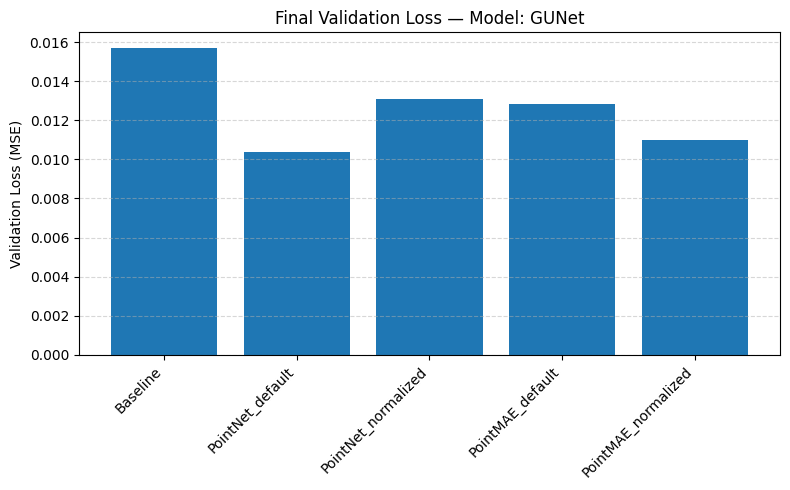

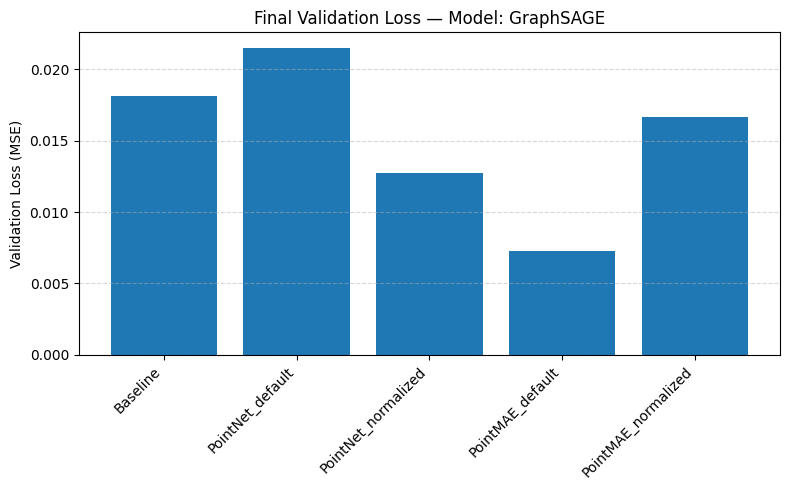

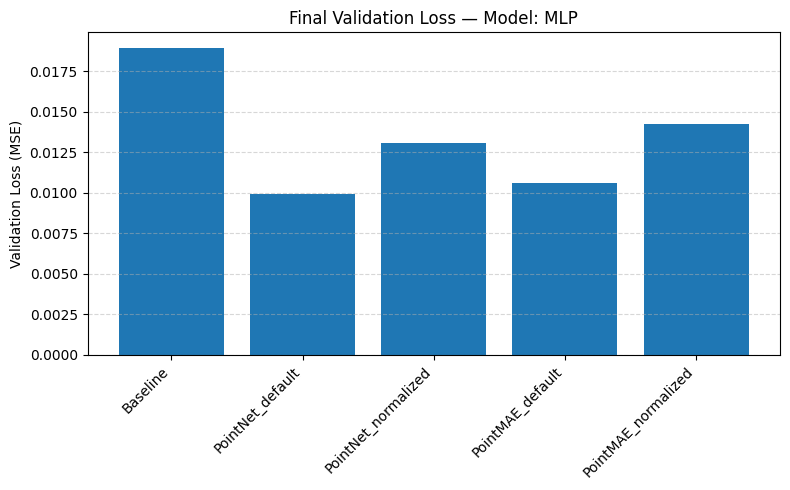

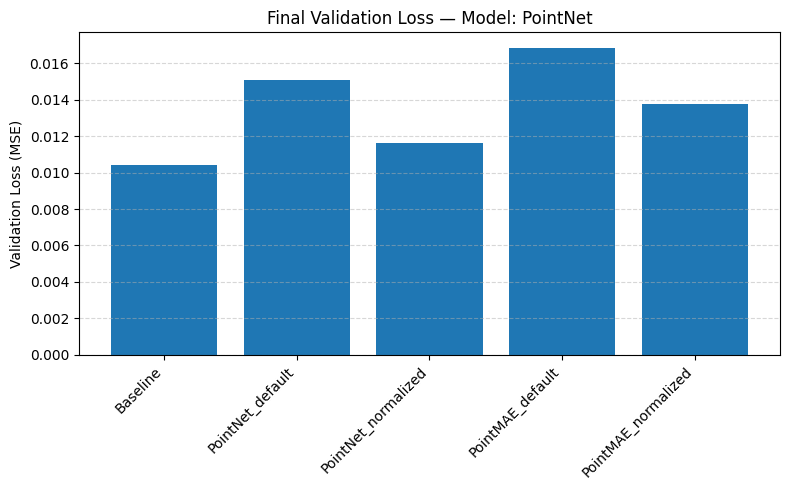

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------
# 1) Lecture du JSON (val_loss)
# --------------------------------------------------------
def load_val_loss(model_path):
    # prend juste le premier JSON dans le dossier
    json_files = [f for f in os.listdir(model_path) if f.endswith(".json")]
    if not json_files:
        return None
    
    json_path = os.path.join(model_path, json_files[0])
    with open(json_path, "r") as f:
        data = json.load(f)

    return data.get("val_loss", None)


root = "."


# --------------------------------------------------------
# 2) Scan des dossiers all_metrics*
# --------------------------------------------------------
rows = []

for folder in os.listdir(root):
    if "all_metrics" not in folder:
        continue

    folder_lower = folder.lower()

    # Détection des conditions
    if "baseline" in folder_lower:
        condition = "Baseline"
    elif "pointnet" in folder_lower and "default" in folder_lower:
        condition = "PointNet_default"
    elif "pointnet" in folder_lower and "normalized" in folder_lower:
        condition = "PointNet_normalized"
    elif "pointmae" in folder_lower and "default" in folder_lower:
        condition = "PointMAE_default"
    elif "pointmae" in folder_lower and "normalized" in folder_lower:
        condition = "PointMAE_normalized"
    else:
        continue

    dataset_path = os.path.join(root, folder)

    # tasks → models → JSON
    for task in os.listdir(dataset_path):
        task_path = os.path.join(dataset_path, task)
        if not os.path.isdir(task_path):
            continue

        for model in os.listdir(task_path):
            model_path = os.path.join(task_path, model)
            if not os.path.isdir(model_path):
                continue

            val_loss = load_val_loss(model_path)
            if val_loss is None:
                continue

            rows.append({
                "Model": model,
                "Condition": condition,
                "Val_Loss": val_loss
            })


# --------------------------------------------------------
# 3) DataFrame + unification des noms
# --------------------------------------------------------
df_val = pd.DataFrame(rows)

model_map = {
    "GraphSAGE": "GraphSAGE",
    "GraphSAGEGlobal": "GraphSAGE",
    "GUNet": "GUNet",
    "GUNetGlobal": "GUNet",
    "MLP": "MLP",
    "MLPGlobal": "MLP",
    "PointNet": "PointNet",
    "PointNetGlobal": "PointNet"
}

df_val["ModelUnified"] = df_val["Model"].map(model_map)

print(df_val)


# --------------------------------------------------------
# 4) Barplots par modèle
# --------------------------------------------------------
conditions_order = [
    "Baseline",
    "PointNet_default",
    "PointNet_normalized",
    "PointMAE_default",
    "PointMAE_normalized"
]

models = sorted(df_val["ModelUnified"].unique())

for model in models:

    data = (
        df_val[df_val["ModelUnified"] == model]
        .groupby("Condition")["Val_Loss"]
        .mean()
        .reindex(conditions_order)
        .dropna()
    )

    plt.figure(figsize=(8,5))
    plt.bar(data.index, data.values)
    plt.ylabel("Validation Loss (MSE)")
    plt.title(f"Final Validation Loss — Model: {model}")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
